## Import

In [1]:
from pathlib import Path
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
from xml.etree.ElementTree import fromstring, ElementTree
from Evtx.Evtx import Evtx
import csv

In [2]:
%load_ext autoreload
%autoreload 2
import preprocess
import main
import a
from unmask_attributes import process_csv
import embedding_converter
import train_score_bert
import test_score_bert
import test_score_bert_v1
import diagnosis
import diagnosis_v1

/home/ubuntu/My_lad/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
INTERIM_DIR = Path('../data/interim')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR = Path('../data/raw')
NO_MEANING_DIR = Path('../data/no_meaning')
PROJECT_ROOT = Path("../")

# データ作成

## refine データ作成
- securityログ
- T1105, (VSCode1), WEB1, WEB2　を含む（12/28時点ではWEB2のアノマリーは含まず）
- integrated を流用

In [ ]:
df = pd.read_csv(INTERIM_DIR/"Integrated/security2_structured.csv") 

In [5]:
cond = (df["Label"] == "anomaly") & (df["project"] == "WEB2")

idx = df.index[cond]
if len(idx) > 0:
    df = df.loc[:idx[0]-1]
    
df.loc[df["project"] == "WEB2", "project"] = "WEB2_C"
df.to_csv(INTERIM_DIR/"refine/security2_structured.csv")

# 検証

## Windows（LogBERT）

### 素

In [ ]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured.csv",
    output_dir = PROCESSED_DIR/"refine_time",
    window_size = 1800, # 30min
    step_size = 900,
    mode = "time",
)

/home/siwamura/My_lad/src/preprocess.py:1006: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 3154 instances (sliding windows) in this dataset

there are 864 instances (sliding windows) in this dataset

there are 1100 instances (sliding windows) in this dataset

there are 805 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine_time/ratio_0.8/train_projects.csv
Project info saved to ../data/processed/refine_time/ratio_0.8/test_normal_projects.csv
Project info saved to ../data/processed/refine_time/ratio_0.8/test_abnormal_projects.csv
Project info saved to ../data/processed/refine_time/vocab/train_projects.csv
vocab size 5620
Sequence Length Statistics Report
Generated: 2025-12-21 21:57:25
Mode: time
Window Size: 1800
Step Size: 900

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    4,496
    Avg Len:  461.97
    Min Len:  97
    Max Len:  22258
    Std Dev:  479.56
  test_normal:
    Count:    1,124
    Avg Len:  481.16
    Min Len:  5
    Max Len:  21798
    Std Dev:  725.68
  test_abnormal:


In [11]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured.csv",
    output_dir = PROCESSED_DIR/"refine_fixed",
    window_size = 430, # 時間ベースの分割における平均値を採用(サンプル数が5000前後になるように調整)
    step_size = 200,
    mode = "fixed",
)

/home/ubuntu/My_lad/src/preprocess.py:1174: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 4248 instances (sliding windows) in this dataset

there are 887 instances (sliding windows) in this dataset

there are 969 instances (sliding windows) in this dataset

there are 720 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine_fixed/train_projects.csv
Project info saved to ../data/processed/refine_fixed/test_normal_projects.csv
Project info saved to ../data/processed/refine_fixed/test_abnormal_projects.csv
Project info saved to ../data/processed/refine_fixed/vocab/train_projects.csv
vocab size 6573
Sequence Length Statistics Report
Generated: 2026-01-12 20:26:31
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    5,258
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_normal:
    Count:    1,315
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_abnormal:
    Count:    251
    Avg Len:  

### unmask & MD5

In [4]:
process_csv(
    input_csv_path=INTERIM_DIR/'refine/security2_structured.csv',
    output_csv_path=INTERIM_DIR/'refine/security2_structured_unmasked.csv',
    no_mask_config="no_mask.json",
    new_column_name='EventTemplateUnmasked',
    hash_method="md5",
)

Loading no_mask config from: no_mask.json
Loading CSV from: ../data/interim/refine/security2_structured.csv
Total rows: 1366109
Columns: ['LineId', 'Level', 'EventID', 'EventRecordID', 'TimeCreated_SystemTime', 'Channel', 'Task', 'Provider_Name', 'Correlation_RelatedActivityID', 'Execution_ProcessID', 'Execution_ThreadID', 'Security_UserID', 'Keywords', 'Content', 'Correlation_ActivityID', 'Provider_Guid', 'Computer', 'Opcode', 'Version', 'Label', 'date', 'project', 'EventId', 'EventTemplate']

Processing EventID: 4688, Attributes: ['ProcessId']
  Found 39423 rows with EventID=4688

Processing EventID: 5156, Attributes: ['ProcessID']
  Found 685614 rows with EventID=5156

Generating MD5 hash column: EventTemplateUnmaskedHash_md5
  Hash column created with 1366109 values (MD5)

Saving result to: ../data/interim/refine/security2_structured_unmasked.csv
Done!

--- Sample of unmasked data ---

EventID 4688:
  Original: SubjectUserSid=<*>|SubjectUserName=<*>|SubjectDomainName=<*>|SubjectLog

In [12]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR/"refine2/fixed",
    event_id="EventTemplateUnmaskedHash_md5",
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed",
)

/home/ubuntu/My_lad/src/preprocess.py:1174: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 4248 instances (sliding windows) in this dataset

there are 887 instances (sliding windows) in this dataset

there are 969 instances (sliding windows) in this dataset

there are 720 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine2/fixed/train_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_normal_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_abnormal_projects.csv
Project info saved to ../data/processed/refine2/fixed/vocab/train_projects.csv
vocab size 6573
Sequence Length Statistics Report
Generated: 2026-01-12 20:27:32
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    5,258
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_normal:
    Count:    1,315
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_abnormal:
    Count:    251
    Avg Le

In [8]:
preprocess.shuffle_elements_per_row(
    input_dir=Path("../data/processed/refine2/fixed"),
    output_dir=Path("../data/processed/refine2/shuffled"),
    random_seed=31,
)

Processing: ../data/processed/refine2/fixed/test_abnormal


Shuffling test_abnormal: 251it [00:00, 3006.76it/s]


  Processed 251 lines -> ../data/processed/refine2/shuffled/test_abnormal
Processing: ../data/processed/refine2/fixed/test_normal


Shuffling test_normal: 1315it [00:00, 4817.83it/s]


  Processed 1315 lines -> ../data/processed/refine2/shuffled/test_normal
Processing: ../data/processed/refine2/fixed/train


Shuffling train: 5258it [00:00, 6209.15it/s]


  Processed 5258 lines -> ../data/processed/refine2/shuffled/train

Shuffle complete. Output saved to: ../data/processed/refine2/shuffled


### unmask & LSH

In [15]:
process_csv(
    input_csv_path=INTERIM_DIR/'refine/security2_structured.csv',
    output_csv_path=INTERIM_DIR/'refine/security2_structured_unmasked.csv',
    no_mask_config="no_mask.json",
    new_column_name='EventTemplateUnmasked',
    hash_method="lsh",
    use_multiprocess=True
)


Loading no_mask config from: no_mask.json
Loading CSV from: ../data/interim/refine/security2_structured.csv
Total rows: 1366109
Columns: ['LineId', 'Level', 'EventID', 'EventRecordID', 'TimeCreated_SystemTime', 'Channel', 'Task', 'Provider_Name', 'Correlation_RelatedActivityID', 'Execution_ProcessID', 'Execution_ThreadID', 'Security_UserID', 'Keywords', 'Content', 'Correlation_ActivityID', 'Provider_Guid', 'Computer', 'Opcode', 'Version', 'Label', 'date', 'project', 'EventId', 'EventTemplate']

Processing EventID: 4688, Attributes: ['SubjectUserSid', 'NewProcessName', 'CommandLine']
  Found 39423 rows with EventID=4688

Processing EventID: 5156, Attributes: ['Application', 'DestPort']
  Found 685614 rows with EventID=5156

Generating LSH (GPU) hash column: EventTemplateUnmaskedHash_lsh
  GPU LSH Progress: 100000/1366109 (7.3%)
  GPU LSH Progress: 200000/1366109 (14.6%)
  GPU LSH Progress: 300000/1366109 (22.0%)
  GPU LSH Progress: 400000/1366109 (29.3%)
  GPU LSH Progress: 500000/13661

In [16]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR/"refine2/fixed",
    event_id="EventTemplateUnmaskedHash_lsh",
    features = ["EventTemplateUnmaskedHash_lsh", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_lsh", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed",
)

/home/ubuntu/My_lad/src/preprocess.py:1008: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 4248 instances (sliding windows) in this dataset

there are 887 instances (sliding windows) in this dataset

there are 969 instances (sliding windows) in this dataset

there are 720 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine2/fixed/train_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_normal_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_abnormal_projects.csv
Project info saved to ../data/processed/refine2/fixed/vocab/train_projects.csv
vocab size 6573
Sequence Length Statistics Report
Generated: 2025-12-31 16:30:54
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    5,258
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_normal:
    Count:    1,315
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_abnormal:
    Count:    251
    Avg Le

### テスト実行部

In [6]:
# train
main.main_cli([
    "train",
    "bert/refine2_",          # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

setup
Building Vocab


100%|██████████| 5258/5258 [00:00<00:00, 17815.16it/s]


VOCAB SIZE: 3806
DEBUG suggest_dataloader: cfg.dataset.vocab.vocab_size = None (type: <class 'str'>)
Updating vocab_size from None to 3806
After update: cfg.dataset.vocab.vocab_size = 3806
before filtering short session
train size  4733
valid size  525


100%|██████████| 5258/5258 [00:02<00:00, 2199.43it/s]


Num of train seqs 4733
Num of valid seqs 525
DEBUG main.py: cfg.dataset.vocab.vocab_size = 3806 (type: <class 'int'>)


...

epoch 9 || TRAIN_Loss:2.8332 ||VAL_Loss:2.7243
Best epoch = 9


147it [00:04, 33.99it/s]
16it [00:00, 95.82it/s]


epoch 10 || TRAIN_Loss:2.8104 ||VAL_Loss:2.7092
Best epoch = 10


137it [00:04, 31.07it/s]


KeyboardInterrupt: 

In [5]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/refine2/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir: ../data/processed/refine2/fixed"
])

../outputs/logbert/bert_no_time/refine2/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 251/251 [00:00<00:00, 5589.91it/s]


VOCAB SIZE: 26985
Updated vocab_size to 26985


100%|██████████| 251/251 [00:01<00:00, 160.08it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.100['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.200['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.300['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.400['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.500['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.600['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.700['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000'

In [ ]:
# train
main.main_cli([
    "train",
    "bert/refine2",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

### 可視化（archive参照）：

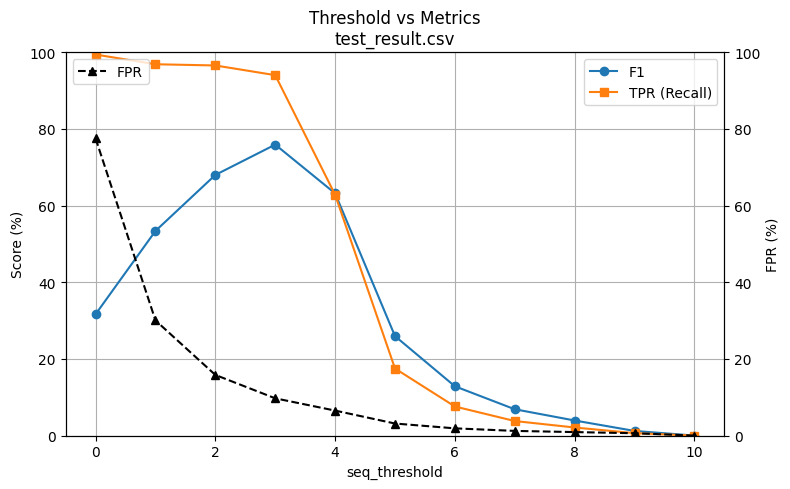

In [6]:
a.plot_threshold_metrics(Path("../archive/10/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

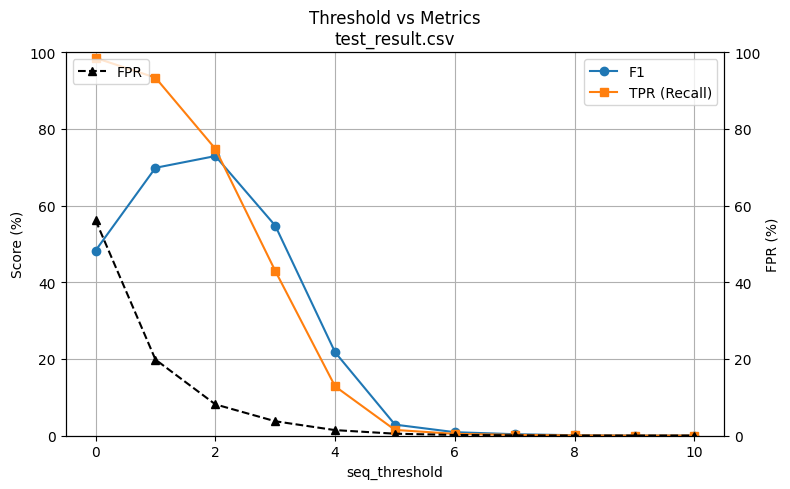

In [17]:
a.plot_threshold_metrics(Path("../archive/9/refine2/time/seq_len_512/r_seed_31/test_result.csv"))

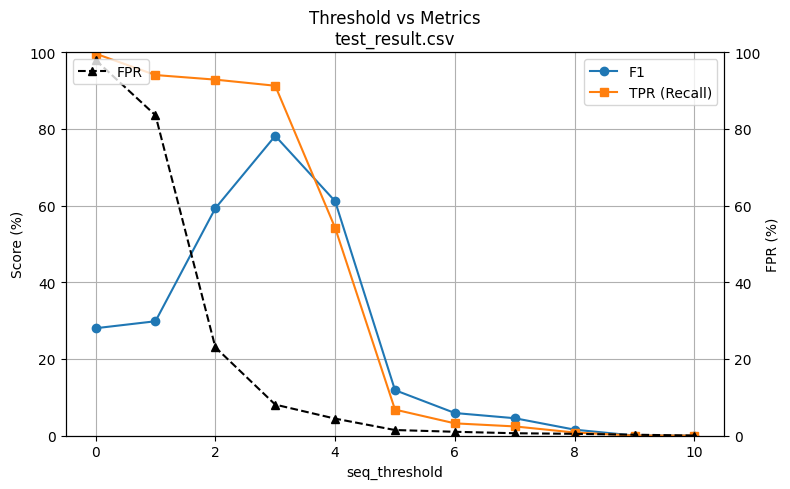

In [12]:
a.plot_threshold_metrics(Path("../archive/8/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

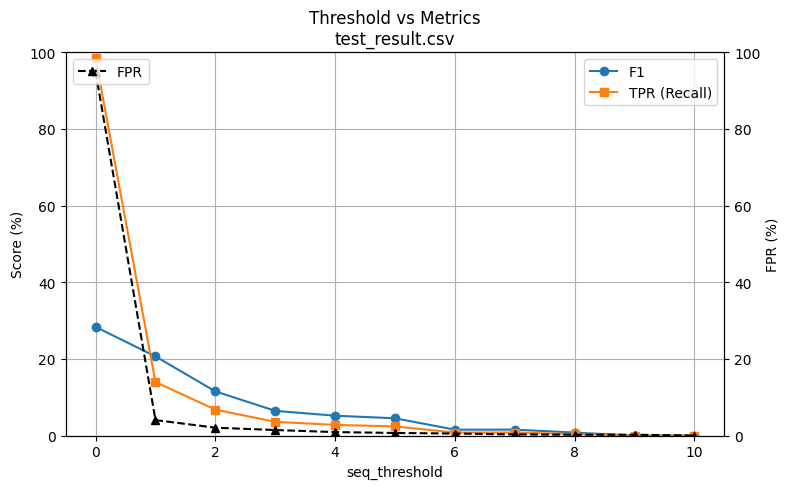

In [12]:
a.plot_threshold_metrics(Path("../archive/7/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

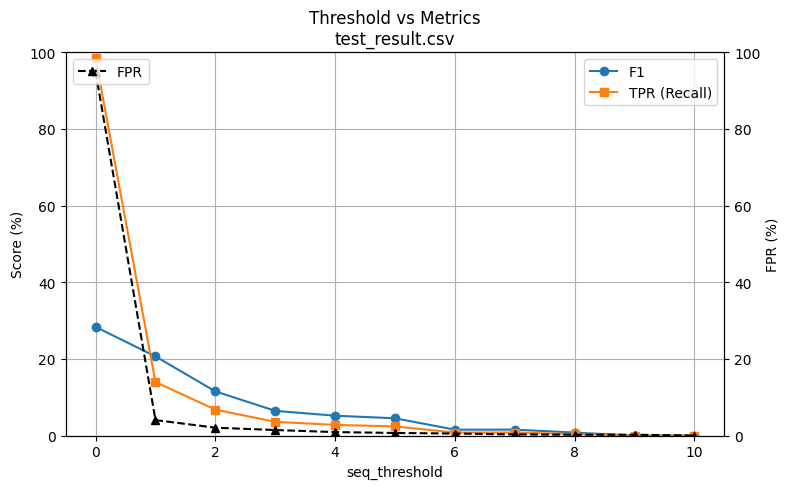

In [7]:
a.plot_threshold_metrics(Path("../archive/6/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

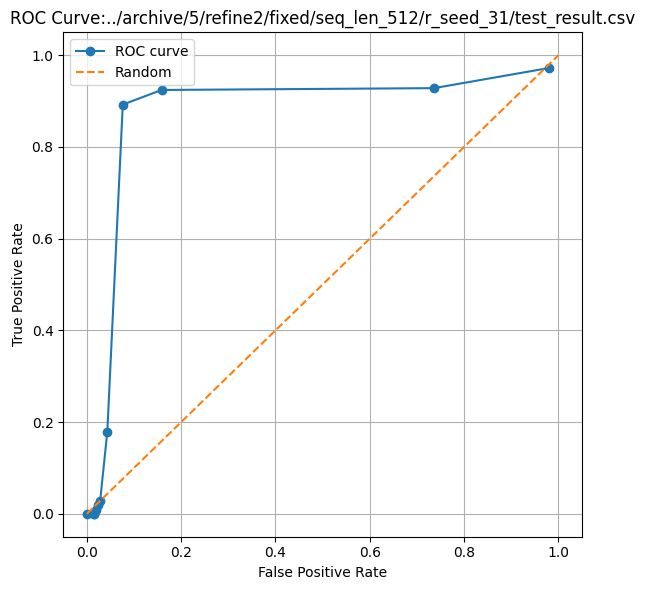

In [8]:
a.plot_roc(Path("../archive/5/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

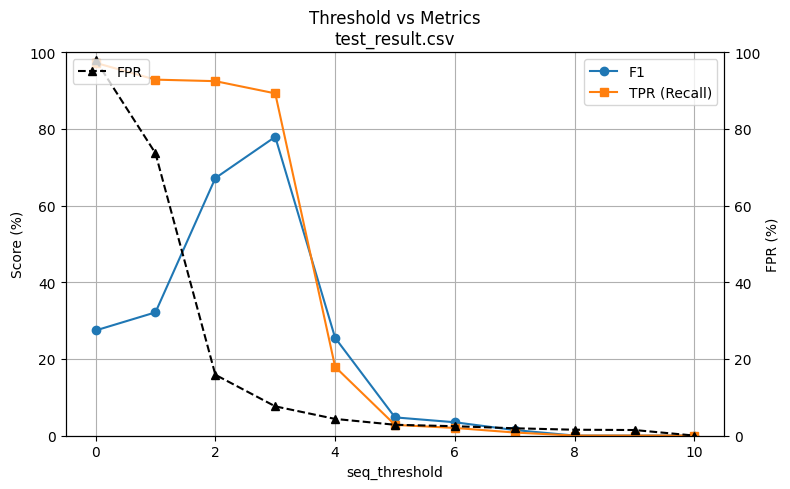

In [5]:
a.plot_threshold_metrics(Path("../archive/5/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

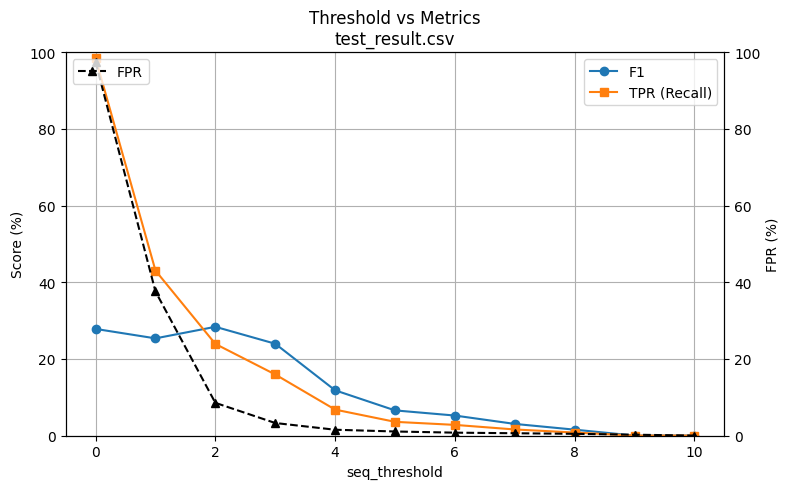

In [19]:
a.plot_threshold_metrics(Path("../archive/4/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

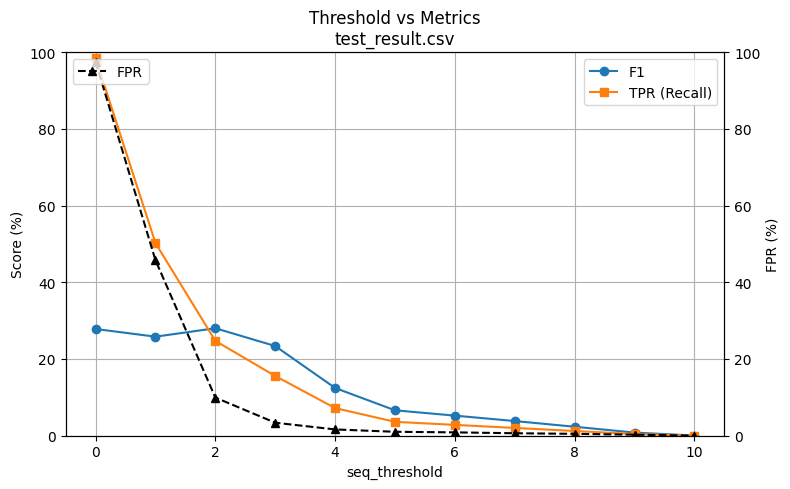

In [14]:
a.plot_threshold_metrics(Path("../archive/3/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

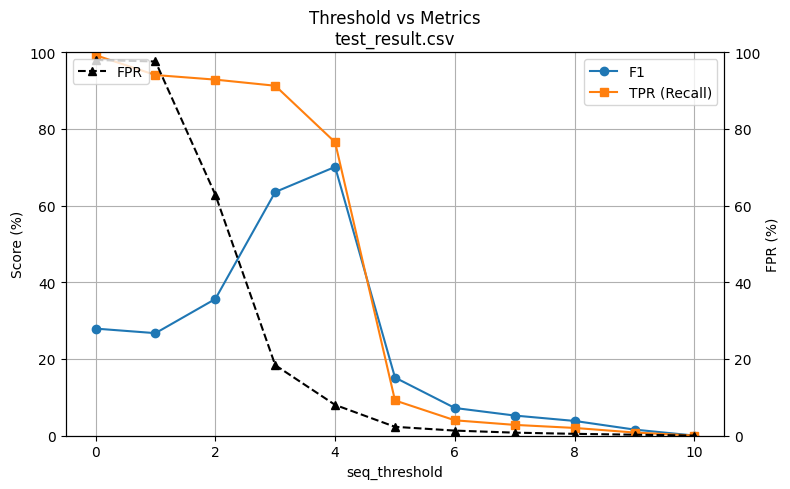

In [9]:
a.plot_threshold_metrics(Path("../archive/2/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

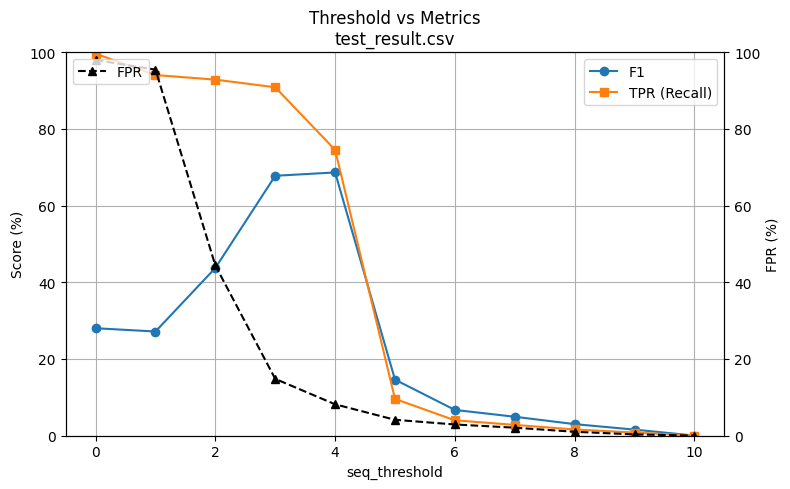

In [9]:
a.plot_threshold_metrics(Path("../archive/1/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

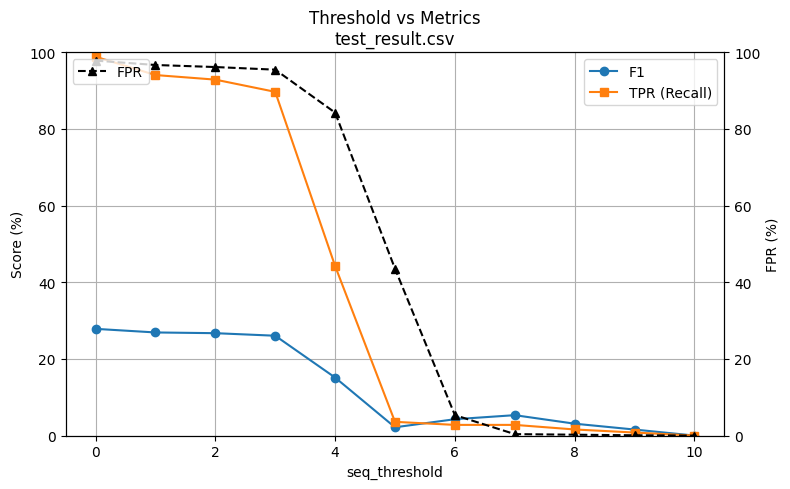

In [ ]:
a.plot_threshold_metrics(Path("../archive/0/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

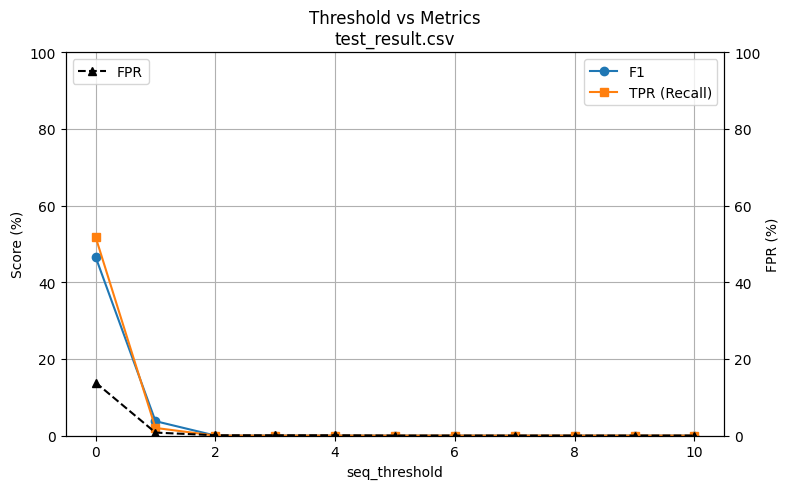

In [8]:
a.plot_threshold_metrics(Path("../output/logbert/bert/refine/fixed/seq_len_512/r_seed_31/test_result.csv"))

## BGL

In [ ]:
preprocess.prepare_bgl_model_data(
    logdata_filepath = INTERIM_DIR/"BGL/BGL_structured.csv",
    output_dir = PROCESSED_DIR/"BGL",
    window_size = 300, # 時間ベースの分割における平均値を採用
    step_size = 60,
    mode = "time",
)

In [17]:
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"BGL/ratio_0.8/train_full"),
    output_file=Path(PROCESSED_DIR/"BGL/ratio_0.8/train")
)

In [ ]:
# train
main.main_cli([
    "train",
    "bert/bgl",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

In [12]:
# テスト
main.main_cli([
    "test",  # run_mode
    "outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "64",   # eval_batchsize
    "cuda:0",     # gpu
])

outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 16268/16268 [00:01<00:00, 9993.12it/s] 


VOCAB SIZE: 237


Processing abnormal test data: 100%|██████████| 2584/2584 [00:01<00:00, 1433.51it/s]


Building Vocab


100%|██████████| 16268/16268 [00:01<00:00, 10361.58it/s]


VOCAB SIZE: 237


100%|██████████| 2584/2584 [00:14<00:00, 179.13it/s]


Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['860.0000', '2578.0000', '2340.0000', '6.0000', '74.9855', '99.7678', '85.6194', '99.7678', '26.8750']
threshold=0.100['558.0000', '2333.0000', '2642.0000', '251.0000', '80.6987', '90.2864', '85.2237', '90.2864', '17.4375']
threshold=0.200['460.0000', '2185.0000', '2740.0000', '399.0000', '82.6087', '84.5588', '83.5724', '84.5588', '14.3750']
threshold=0.300['417.0000', '2038.0000', '2783.0000', '546.0000', '83.0143', '78.8700', '80.8891', '78.8700', '13.0312']
threshold=0.400['390.0000', '1894.0000', '2810.0000', '690.0000', '82.9247', '73.2972', '77.8143', '73.2972', '12.1875']
threshold=0.500['338.0000', '1792.0000', '2862.0000', '792.0000', '84.1315', '69.3498', '76.0289', '69.3498', '10.5625']
threshold=0.600['270.0000', '1688.0000', '2930.0000', '896.0000', '86.2104', '65.3251', '74.3285', '65.3251', '8.4375']
threshold=0.700['263.0000', '1593.0000', '

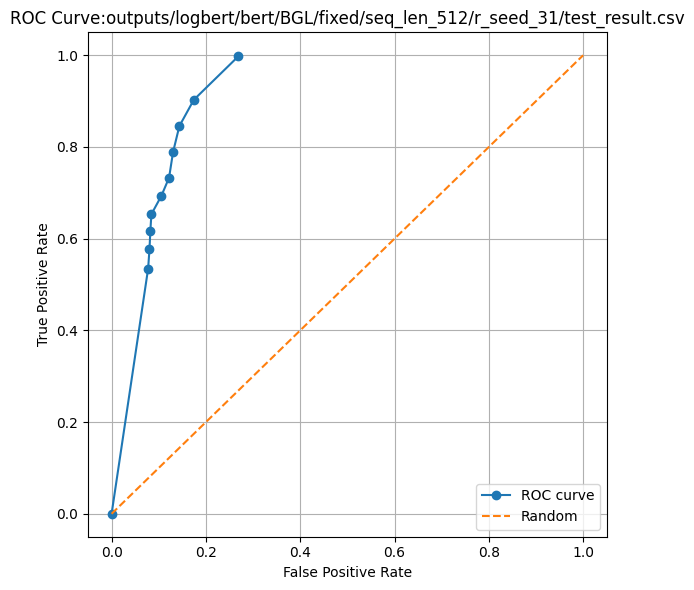

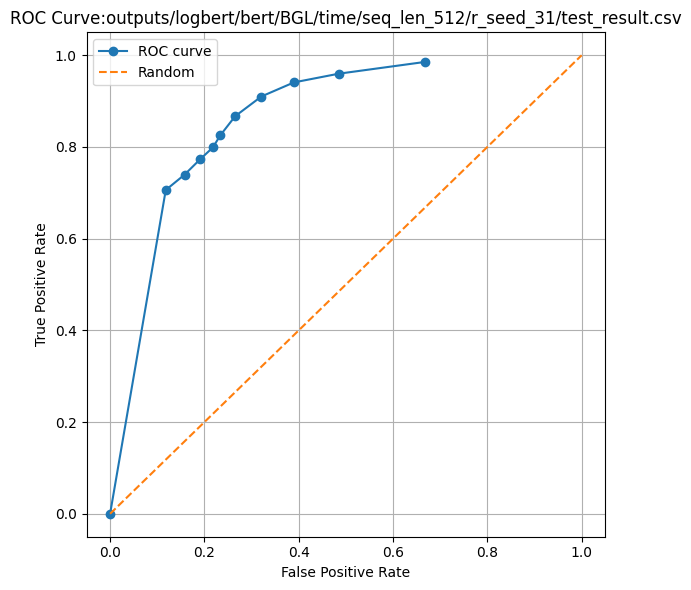

In [19]:
a.plot_roc(Path("outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31/test_result.csv"))
a.plot_roc(Path("outputs/logbert/bert/BGL/time/seq_len_512/r_seed_31/test_result.csv"))


## Tbird

In [28]:
preprocess.prepare_tbird_model_data(
    logdata_filepath = INTERIM_DIR/"Tbird/Thunderbird_structured.csv",
    output_dir = PROCESSED_DIR/"Tbird/fixed",
    window_size = 300, 
    step_size = 150,
    mode = "fixed",
)

/home/siwamura/My_lad/src/preprocess.py:1286: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['deltaT'].fillna(0, inplace=True)


there are 133332 instances (sliding windows) in this dataset

vocab size 79166
Sequence Length Statistics Report
Generated: 2025-12-21 19:40:07
Mode: fixed
Window Size: 300
Step Size: 150

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    63,332
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00
  test_normal:
    Count:    15,834
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00
  test_abnormal:
    Count:    54,166
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00


Statistics saved to: ../data/processed/Tbird/fixed/seq_stats.txt


In [29]:
# サンプル数を5000まで削る
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"Tbird/fixed/train_full"),
    output_file=Path(PROCESSED_DIR/"Tbird/fixed/train")
)

In [30]:
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"Tbird/fixed/test_abnormal_full"),
    output_file=Path(PROCESSED_DIR/"Tbird/fixed/test_abnormal")
)

In [ ]:
# train
main.main_cli([
    "train",
    "bert/tbird",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

In [33]:
# テスト
main.main_cli([
    "test",  # run_mode
    "outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "64",   # eval_batchsize
    "cuda:0",     # gpu
])

outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 79166/79166 [00:04<00:00, 16982.03it/s]


VOCAB SIZE: 1159


100%|██████████| 44892/44892 [03:57<00:00, 188.98it/s]


Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['12613.0000', '44824.0000', '3195.0000', '68.0000', '78.0403', '99.8485', '87.6076', '99.8485', '79.7887']
threshold=0.100['10273.0000', '44351.0000', '5535.0000', '541.0000', '81.1932', '98.7949', '89.1334', '98.7949', '64.9861']
threshold=0.200['9062.0000', '43545.0000', '6746.0000', '1347.0000', '82.7742', '96.9995', '89.3240', '96.9995', '57.3254']
threshold=0.300['8233.0000', '42231.0000', '7575.0000', '2661.0000', '83.6854', '94.0724', '88.5754', '94.0724', '52.0812']
threshold=0.400['7538.0000', '37227.0000', '8270.0000', '7665.0000', '83.1610', '82.9257', '83.0432', '82.9257', '47.6847']
threshold=0.500['6882.0000', '28790.0000', '8926.0000', '16102.0000', '80.7076', '64.1317', '71.4711', '64.1317', '43.5349']
threshold=0.600['6245.0000', '22850.0000', '9563.0000', '22042.0000', '78.5358', '50.8999', '61.7676', '50.8999', '39.5053']
threshold=0.700['

/home/siwamura/My_lad/src/a.py:13: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  tpr = df["TPR"] / 100.0
/home/siwamura/My_lad/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


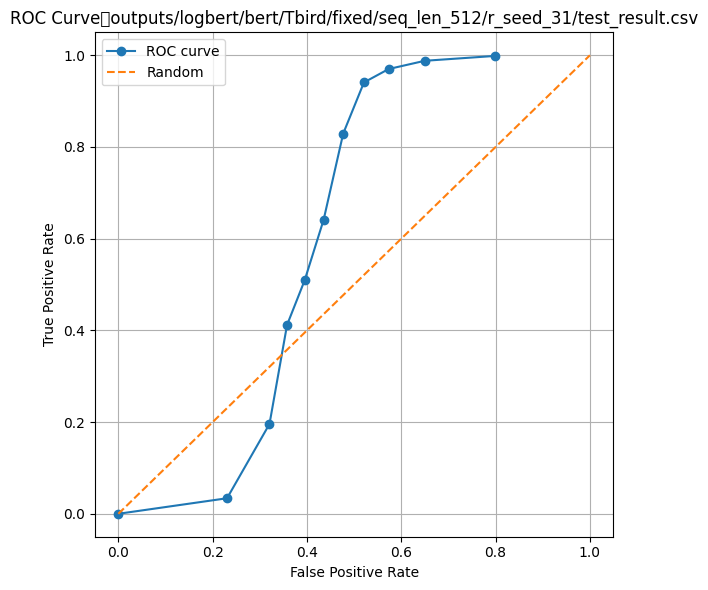

/home/siwamura/My_lad/src/a.py:13: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  tpr = df["TPR"] / 100.0
/home/siwamura/My_lad/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


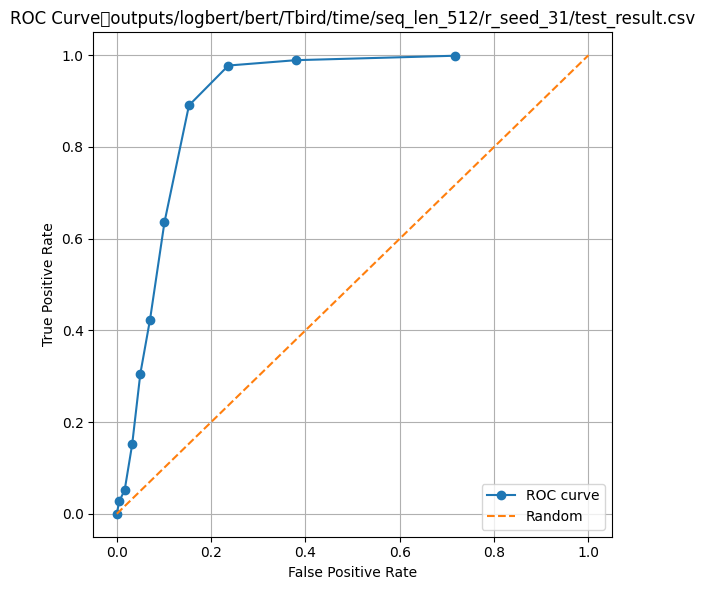

In [43]:
a.plot_roc(Path("outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31/test_result.csv"))
a.plot_roc(Path("outputs/logbert/bert/Tbird/time/seq_len_512/r_seed_31/test_result.csv"))


## Score

#### data

In [ ]:
# [EventID, score, score_missing]
preprocess.prepare_scores_model_data(
    output_dir = PROCESSED_DIR / "scores",
    #output_dir = Path("../data_tmp/scores"),
    window_size = 400,
    step_size = 200,
    mode = "fixed",
)

there are 9659 instances (sliding windows) in this dataset

there are 615 instances (sliding windows) in this dataset

there are 1357 instances (sliding windows) in this dataset

there are 581 instances (sliding windows) in this dataset

there are 1365 instances (sliding windows) in this dataset

there are 584 instances (sliding windows) in this dataset

Project info saved to ../data/processed/scores/fixed/train_projects.csv
Project info saved to ../data/processed/scores/fixed/test_normal_projects.csv
Project info saved to ../data/processed/scores/fixed/test_abnormal_projects.csv


In [9]:
embedding_converter.main(PROJECT_ROOT)

=== Loading embedding mapping ===
Loaded 425 embeddings (dim=384)

=== Converting train ===
Loaded 12381 instances
Saved embedded data to ../data/processed/scores/fixed_embedded/train.npz

=== Converting test_normal ===
Loaded 807 instances
Saved embedded data to ../data/processed/scores/fixed_embedded/test_normal.npz

=== Converting test_abnormal ===
Loaded 973 instances
Saved embedded data to ../data/processed/scores/fixed_embedded/test_abnormal.npz

=== Conversion complete ===


#### train

In [4]:
train_score_bert.run_from_notebook("score_bert")

Output directory: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/
Device: cuda:0
Config: score_bert
Loading data from ../data/processed/scores/fixed_embedded/train.npz
Total samples: 12381
Training samples: 11143 (90%)
Validation samples: 1238 (10%)
Input dimension: 386, Sequence length: 200
Model parameters: 793,729


Epoch 1: 100%|██████████| 349/349 [00:03<00:00, 115.02it/s, loss=0.0103, score=31.7442, event=0.0103]


Epoch 1/70 - Train Loss: 0.0179 - Val Loss: 0.0171 - LR: 0.000100
  Saved best model (loss: 0.0171)


Epoch 2: 100%|██████████| 349/349 [00:02<00:00, 123.28it/s, loss=0.0131, score=5.2957, event=0.0131] 


Epoch 2/70 - Train Loss: 0.0150 - Val Loss: 0.0142 - LR: 0.000100
  Saved best model (loss: 0.0142)


...

Epoch 70: 100%|██████████| 349/349 [00:02<00:00, 125.06it/s, loss=0.0054, score=18.4469, event=0.0054]


Epoch 70/70 - Train Loss: 0.0068 - Val Loss: 0.0061 - LR: 0.000001
Loss history plot saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/loss_history.png

Computing error statistics for normalization...


Computing stats: 100%|██████████| 387/387 [00:01<00:00, 295.53it/s]


Error statistics saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/error_stats.json
  μ_score: 15.570488, σ_score: 99.001815
  μ_event: 0.014073, σ_event: 0.019182
  Score tokens: 2,386,696, Event tokens: 2,476,200

Training complete!
Best validation loss: 0.0061
Results saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847


0.006069887369775619

#### test

In [10]:
results = test_score_bert_v1.run_from_notebook("../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/", gamma=1.0)
print(f"ROC-AUC: {results['roc_auc']}")

Model loaded from: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847
Best epoch: 57, Best loss: 0.0061

Loading test data...
  Normal: ../data/processed/scores/fixed_embedded/test_normal.npz
  Abnormal: ../data/processed/scores/fixed_embedded/test_abnormal.npz
  Normal windows: 807
  Abnormal windows: 973

Computing anomaly scores (γ=1.0, percentile=95)...
  Formula: window_score = P95(raw_score_err) + γ * P95(event_context_err)


  Normal scores: mean=83.9189, std=225.2098
  Abnormal scores: mean=406.0961, std=2729.6267

Generating plots...
Timeline plot saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/eval_v1/timeline_v1.png
Score components plot saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/eval_v1/score_components_v1.png
ROC/PR curves saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/eval_v1/roc_pr_curves_v1.png
Metrics curves saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/eval_v1/metrics_curves_v1.png

EVALUATION RESULTS (V1 - Percentile-based)
Scoring: P95(score_err) + 1.0 * P95(event_err)
ROC-AUC: 0.5051
PR-AUC:  0.5451
Best F1: 0.7069 (threshold=0.0962)
Results saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/eval_v1
ROC-AUC: 0.5050973559973052


#### diagnorsis

In [ ]:
results = diagnosis_v1.run_from_notebook("../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847",gamma=1.0)

Running diagnosis (V1) for: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847
  Formula: window_score = P95(raw_score_err) + 10 * P95(event_context_err)

Loading test data...
  Normal windows: 807
  Abnormal windows: 973

Computing detailed statistics (raw errors)...



Generating diagnosis plots (V1)...
Raw histograms saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/diagnosis_v1/histograms_raw_v1.png
Combined histograms saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/diagnosis_v1/combined_histograms_v1.png
Missing ratio plot saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/diagnosis_v1/missing_ratio_v1.png
Raw error histograms saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/diagnosis_v1/error_raw_histograms_v1.png
Score-Event scatter plot saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/diagnosis_v1/score_event_scatter_v1.png

DIAGNOSIS RESULTS (V1 - Percentile-based)

Scoring Formula:
  window_score = P95(raw_score_err) + 10 × P95(event_context_err)

Separate AUC Evaluation (P95-based):
  Score Part AUC:  0.5053
  Event Part AUC:  0.5571

Aggregation

# 追加検証

## train(T1105) ⇒ test(T1105, WEB1, WEB2)
- プロジェクト名：ex1

### 下準備（ハッシュ値の用意）

In [12]:
projects = ["T1105(full)", "WEB1", "WEB2"]

for project in projects:
    process_csv(
        input_csv_path=INTERIM_DIR/f'{project}/security2_structured.csv',
        output_csv_path=INTERIM_DIR/f'{project}/security2_structured_unmasked.csv',
        no_mask_config="no_mask.json",
        new_column_name='EventTemplateUnmasked',
        hash_method="md5",
    )

Loading no_mask config from: no_mask.json
Loading CSV from: ../data/interim/T1105(full)/security2_structured.csv
Total rows: 1027687
Columns: ['Level', 'EventID', 'EventRecordID', 'TimeCreated_SystemTime', 'Channel', 'Task', 'Provider_Name', 'Correlation_RelatedActivityID', 'Execution_ProcessID', 'Execution_ThreadID', 'Security_UserID', 'Keywords', 'Content', 'Correlation_ActivityID', 'Provider_Guid', 'Computer', 'Opcode', 'Version', 'Label', 'EventId', 'EventTemplate']

Processing EventID: 4688, Attributes: ['ProcessId']
  Found 24249 rows with EventID=4688

Processing EventID: 5156, Attributes: ['ProcessID']
  Found 522459 rows with EventID=5156

Generating MD5 hash column: EventTemplateUnmaskedHash_md5
  Hash column created with 1027687 values (MD5)

Saving result to: ../data/interim/T1105(full)/security2_structured_unmasked.csv
Done!

--- Sample of unmasked data ---

EventID 4688:
  Original: SubjectUserSid=<*>|SubjectUserName=<*>|SubjectDomainName=<*>|SubjectLogonId=<*>|NewProcess

### モデル前データ作成

In [7]:
preprocess.prepare_model_train_data(
    logdata_filepath = INTERIM_DIR / "T1105(full)/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex1",
    train_ratio=0.94,
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:864: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 5137 instances (sliding windows) in this dataset

training size 4822
Sequence Length Statistics Report
Generated: 2026-01-12 18:53:02
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.94]
--------------------------------------------------
  train:
    Count:    4,822
    Avg Len:  4822.00
    Min Len:  4822
    Max Len:  4822
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex1/seq_stats.txt


In [8]:
preprocess.prepare_model_test_data(
    logdata_filepath = INTERIM_DIR / "T1105(full)/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex1/T1105(full)",
    train_ratio=0.94,
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:942: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 5137 instances (sliding windows) in this dataset

test normal size 308
test abnormal size 7
Sequence Length Statistics Report
Generated: 2026-01-12 19:45:29
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.94]
--------------------------------------------------
  test_normal:
    Count:    308
    Avg Len:  308.00
    Min Len:  308
    Max Len:  308
    Std Dev:  0.00
  test_abnormal:
    Count:    7
    Avg Len:  7.00
    Min Len:  7
    Max Len:  7
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex1/T1105(full)/seq_stats.txt


In [ ]:
preprocess.prepare_model_test_data(
    logdata_filepath = INTERIM_DIR / "WEB1/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex1/WEB1",
    train_ratio=0.7,
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

preprocess.prepare_model_test_data(
    logdata_filepath = INTERIM_DIR / "WEB2/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex1/WEB2",
    train_ratio=0.7,
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:942: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 969 instances (sliding windows) in this dataset

test normal size 218
test abnormal size 243
Sequence Length Statistics Report
Generated: 2026-01-12 18:53:40
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.7]
--------------------------------------------------
  test_normal:
    Count:    218
    Avg Len:  218.00
    Min Len:  218
    Max Len:  218
    Std Dev:  0.00
  test_abnormal:
    Count:    243
    Avg Len:  243.00
    Min Len:  243
    Max Len:  243
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex1/WEB1/seq_stats.txt


/home/ubuntu/My_lad/src/preprocess.py:942: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 1077 instances (sliding windows) in this dataset

test normal size 248
test abnormal size 251
Sequence Length Statistics Report
Generated: 2026-01-12 18:53:44
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.7]
--------------------------------------------------
  test_normal:
    Count:    248
    Avg Len:  248.00
    Min Len:  248
    Max Len:  248
    Std Dev:  0.00
  test_abnormal:
    Count:    251
    Avg Len:  251.00
    Min Len:  251
    Max Len:  251
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex1/WEB2/seq_stats.txt


### Train

In [ ]:
# train
main.main_cli([
    "train",
    "bert/ex1",           # conf/bert_config_name.yaml
])

### Test

In [16]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/ex1/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/ex1/T1105(full)",
])

../outputs/logbert/bert_no_time/ex1/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 7 vocab source files:
  - ../data/processed/ex1/train
  - ../data/processed/ex1/T1105(full)/test_abnormal
  - ../data/processed/ex1/T1105(full)/test_normal
  - ../data/processed/ex1/WEB1/test_abnormal
  - ../data/processed/ex1/WEB1/test_normal
  - ../data/processed/ex1/WEB2/test_abnormal
  - ../data/processed/ex1/WEB2/test_normal
Total lines processed: 6097
Building Vocab


100%|██████████| 6097/6097 [00:00<00:00, 16940.38it/s]


VOCAB SIZE: 3874
Updated vocab_size to 3874


100%|██████████| 7/7 [00:00<00:00, 30.68it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['282.0000', '7.0000', '6.0000', '0.0000', '2.4221', '100.0000', '4.7297', '100.0000', '97.9167']
threshold=0.100['91.0000', '7.0000', '197.0000', '0.0000', '7.1429', '100.0000', '13.3333', '100.0000', '31.5972']
threshold=0.200['21.0000', '7.0000', '267.0000', '0.0000', '25.0000', '100.0000', '40.0000', '100.0000', '7.2917']
threshold=0.300['15.0000', '7.0000', '273.0000', '0.0000', '31.8182', '100.0000', '48.2759', '100.0000', '5.2083']
threshold=0.400['11.0000', '6.0000', '277.0000', '1.0000', '35.2941', '85.7143', '50.0000', '85.7143', '3.8194']
threshold=0.500['7.0000', '0.0000', '281.0000', '7.0000', '0.0000', '0.0000', '0.0000', '0.0000', '2.4306']
threshold=0.600['7.0000', '0.0000', '281.0000', '7.0000', '0.0000', '0.0000', '0.0000', '0.0000', '2.4306']
threshold=0.700['4.0000', '0.0000', '284.0000', '7.0000', '0.0000', '0.0000', '0.0000', '0.0000', '

In [17]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/ex1/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/ex1/WEB1"
])

../outputs/logbert/bert_no_time/ex1/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 7 vocab source files:
  - ../data/processed/ex1/train
  - ../data/processed/ex1/T1105(full)/test_abnormal
  - ../data/processed/ex1/T1105(full)/test_normal
  - ../data/processed/ex1/WEB1/test_abnormal
  - ../data/processed/ex1/WEB1/test_normal
  - ../data/processed/ex1/WEB2/test_abnormal
  - ../data/processed/ex1/WEB2/test_normal
Total lines processed: 6097
Building Vocab


100%|██████████| 6097/6097 [00:00<00:00, 19995.88it/s]


VOCAB SIZE: 3874
Updated vocab_size to 3874


100%|██████████| 243/243 [00:00<00:00, 245.35it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['191.0000', '242.0000', '1.0000', '1.0000', '55.8891', '99.5885', '71.5976', '99.5885', '99.4792']
threshold=0.100['191.0000', '228.0000', '1.0000', '15.0000', '54.4153', '93.8272', '68.8822', '93.8272', '99.4792']
threshold=0.200['191.0000', '225.0000', '1.0000', '18.0000', '54.0865', '92.5926', '68.2853', '92.5926', '99.4792']
threshold=0.300['190.0000', '220.0000', '2.0000', '23.0000', '53.6585', '90.5350', '67.3813', '90.5350', '98.9583']
threshold=0.400['181.0000', '134.0000', '11.0000', '109.0000', '42.5397', '55.1440', '48.0287', '55.1440', '94.2708']
threshold=0.500['21.0000', '20.0000', '171.0000', '223.0000', '48.7805', '8.2305', '14.0845', '8.2305', '10.9375']
threshold=0.600['13.0000', '8.0000', '179.0000', '235.0000', '38.0952', '3.2922', '6.0606', '3.2922', '6.7708']
threshold=0.700['11.0000', '6.0000', '181.0000', '237.0000', '35.2941', '2.469

In [18]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/ex1/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/ex1/WEB2"
])

../outputs/logbert/bert_no_time/ex1/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 7 vocab source files:
  - ../data/processed/ex1/train
  - ../data/processed/ex1/T1105(full)/test_abnormal
  - ../data/processed/ex1/T1105(full)/test_normal
  - ../data/processed/ex1/WEB1/test_abnormal
  - ../data/processed/ex1/WEB1/test_normal
  - ../data/processed/ex1/WEB2/test_abnormal
  - ../data/processed/ex1/WEB2/test_normal
Total lines processed: 6097
Building Vocab


100%|██████████| 6097/6097 [00:00<00:00, 20216.01it/s]


VOCAB SIZE: 3874
Updated vocab_size to 3874


100%|██████████| 251/251 [00:01<00:00, 243.46it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['217.0000', '250.0000', '7.0000', '1.0000', '53.5332', '99.6016', '69.6379', '99.6016', '96.8750']
threshold=0.100['216.0000', '236.0000', '8.0000', '15.0000', '52.2124', '94.0239', '67.1408', '94.0239', '96.4286']
threshold=0.200['215.0000', '233.0000', '9.0000', '18.0000', '52.0089', '92.8287', '66.6667', '92.8287', '95.9821']
threshold=0.300['213.0000', '228.0000', '11.0000', '23.0000', '51.7007', '90.8367', '65.8960', '90.8367', '95.0893']
threshold=0.400['198.0000', '142.0000', '26.0000', '109.0000', '41.7647', '56.5737', '48.0541', '56.5737', '88.3929']
threshold=0.500['27.0000', '20.0000', '197.0000', '231.0000', '42.5532', '7.9681', '13.4228', '7.9681', '12.0536']
threshold=0.600['10.0000', '8.0000', '214.0000', '243.0000', '44.4444', '3.1873', '5.9480', '3.1873', '4.4643']
threshold=0.700['8.0000', '6.0000', '216.0000', '245.0000', '42.8571', '2.390

### 可視化

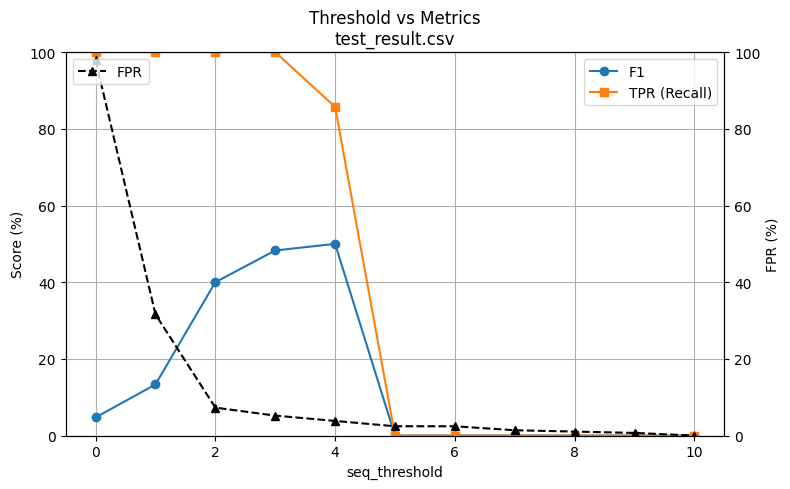

In [19]:
a.plot_threshold_metrics(Path("../archive/11/T1105/test_result.csv"))

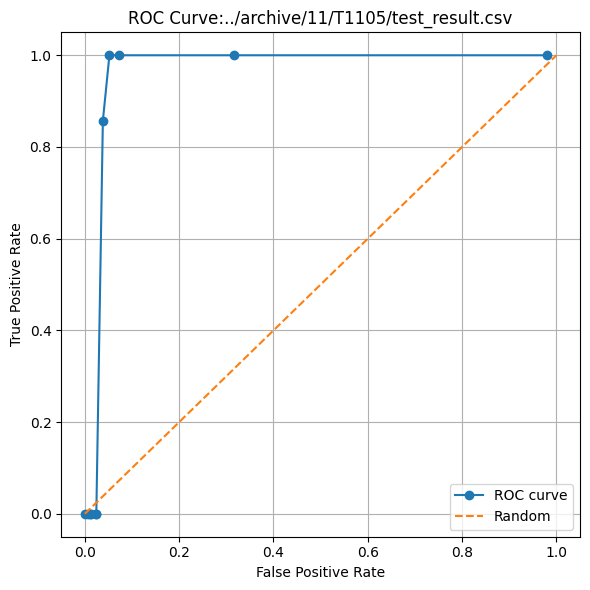

In [22]:
a.plot_roc(Path("../archive/11/T1105/test_result.csv"))

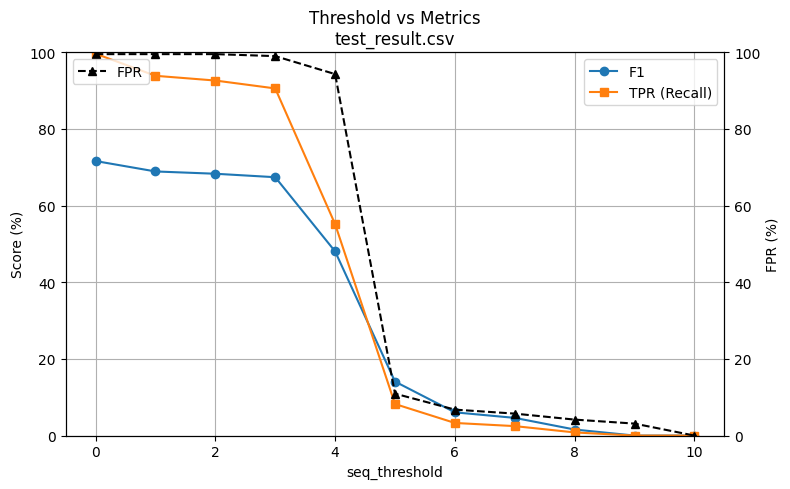

In [20]:
a.plot_threshold_metrics(Path("../archive/11/WEB1/test_result.csv"))

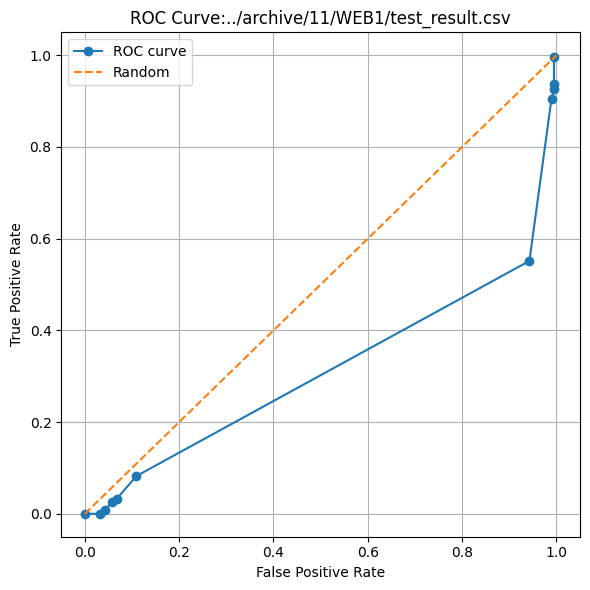

In [23]:
a.plot_roc(Path("../archive/11/WEB1/test_result.csv"))

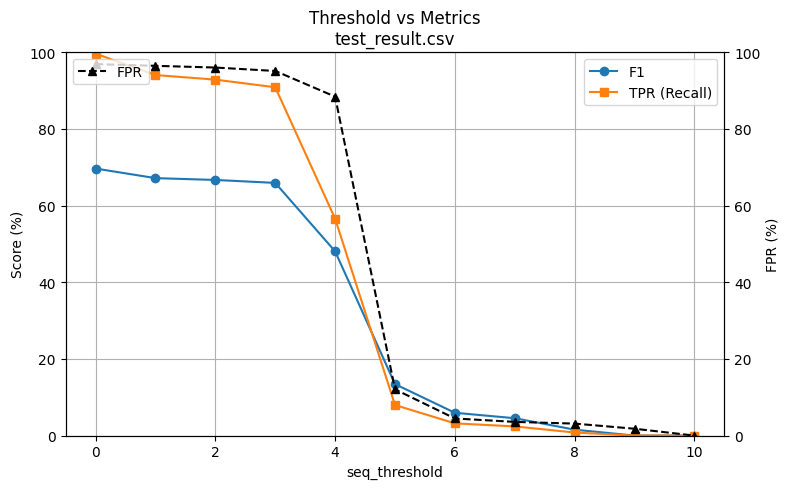

In [21]:
a.plot_threshold_metrics(Path("../archive/11/WEB2/test_result.csv"))

## train(WEB1) ⇒ test(WEB1)
- プロジェクト名：ex2
- 次実験の前段

### モデル前データ作成

In [5]:
preprocess.prepare_model_train_data(
    logdata_filepath = INTERIM_DIR / "WEB1/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex2",
    train_ratio=0.7,
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:864: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 969 instances (sliding windows) in this dataset

training size 508
Sequence Length Statistics Report
Generated: 2026-01-14 05:09:08
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.7]
--------------------------------------------------
  train:
    Count:    508
    Avg Len:  508.00
    Min Len:  508
    Max Len:  508
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex2/seq_stats.txt


### 検証

In [ ]:
# train
main.main_cli([
    "train",
    "bert/ex2",           # conf/bert_config_name.yaml
])

In [6]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/ex2/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/ex2/WEB1",
])

../outputs/logbert/bert_no_time/ex2/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 3 vocab source files:
  - ../data/processed/ex2/train
  - ../data/processed/ex2/WEB1/test_abnormal
  - ../data/processed/ex2/WEB1/test_normal
Total lines processed: 969
Building Vocab


100%|██████████| 969/969 [00:00<00:00, 16028.49it/s]

VOCAB SIZE: 1734
Updated vocab_size to 1734



100%|██████████| 243/243 [00:01<00:00, 213.22it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['190.0000', '240.0000', '2.0000', '3.0000', '55.8140', '98.7654', '71.3224', '98.7654', '98.9583']
threshold=0.100['53.0000', '228.0000', '139.0000', '15.0000', '81.1388', '93.8272', '87.0229', '93.8272', '27.6042']
threshold=0.200['13.0000', '92.0000', '179.0000', '151.0000', '87.6190', '37.8601', '52.8736', '37.8601', '6.7708']
threshold=0.300['7.0000', '38.0000', '185.0000', '205.0000', '84.4444', '15.6379', '26.3889', '15.6379', '3.6458']
threshold=0.400['5.0000', '20.0000', '187.0000', '223.0000', '80.0000', '8.2305', '14.9254', '8.2305', '2.6042']
threshold=0.500['3.0000', '8.0000', '189.0000', '235.0000', '72.7273', '3.2922', '6.2992', '3.2922', '1.5625']
threshold=0.600['2.0000', '6.0000', '190.0000', '237.0000', '75.0000', '2.4691', '4.7809', '2.4691', '1.0417']
threshold=0.700['2.0000', '2.0000', '190.0000', '241.0000', '50.0000', '0.8230', '1.6194

### 可視化

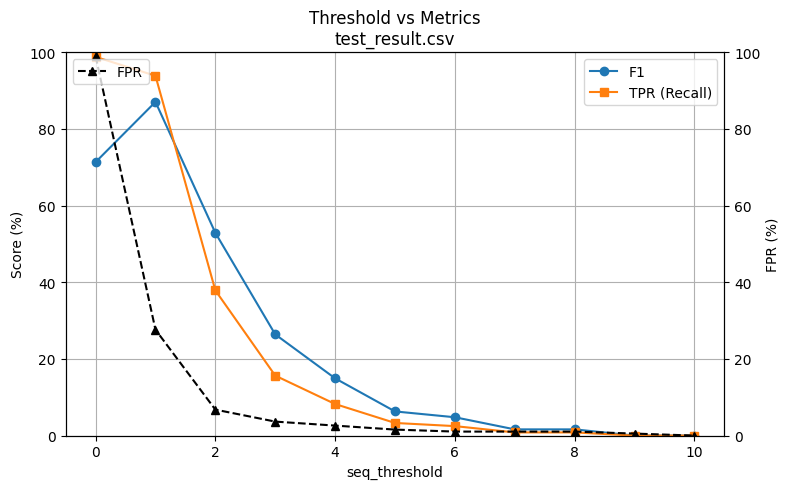

In [7]:
a.plot_threshold_metrics(Path("../archive/12/test_result.csv"))

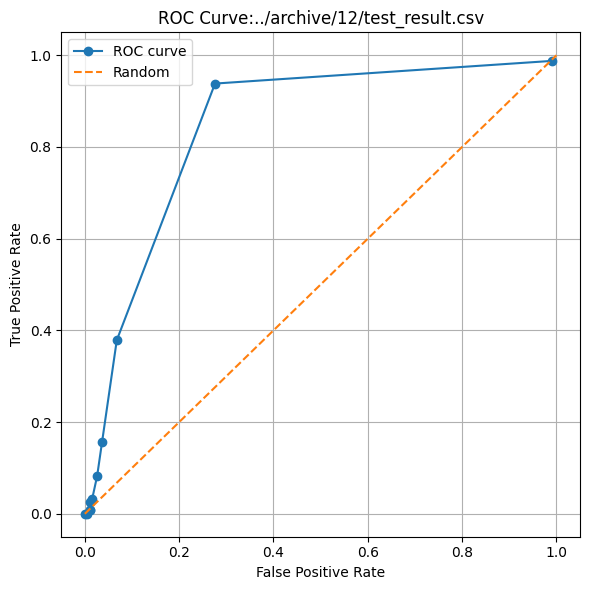

In [17]:
a.plot_roc(Path("../archive/12/test_result.csv"))

## train(T1105 ＋ WEB1) ⇒ test(WEB1)
- プロジェクト名：ex3

### モデル前データ作成

In [9]:
preprocess.merge_processed_files(
    file_path1=PROCESSED_DIR/"ex1"/"train", # T1105のtrain
    file_path2=PROCESSED_DIR/"ex2"/"train", # WEB1のtrain
    output_dir=PROCESSED_DIR/"ex3",
    output_filename="train",  # 結合後のファイル名
    mode="fixed",               # seq_stats.txt用のモード
    window_size=430,            # seq_stats.txt用のウィンドウサイズ
    step_size=200,              # seq_stats.txt用のステップサイズ
)

Merged 4822 lines from train
Merged 508 lines from train
Total: 5330 lines
Output saved to: ../data/processed/ex3/train
Sequence Length Statistics Report
Generated: 2026-01-14 16:48:34
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: merged]
--------------------------------------------------
  train:
    Count:    5,330
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex3/seq_stats.txt


### 検証

In [ ]:
# train
main.main_cli([
    "train",
    "bert/ex3",           # conf/bert_config_name.yaml
])

In [15]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/ex3/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/ex2/WEB1",
])

../outputs/logbert/bert_no_time/ex3/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 3 vocab source files:
  - ../data/processed/ex3/train
  - ../data/processed/ex3/WEB1/test_abnormal
  - ../data/processed/ex3/WEB1/test_normal
Total lines processed: 5791
Building Vocab


100%|██████████| 5791/5791 [00:00<00:00, 17656.23it/s]


VOCAB SIZE: 4004
Updated vocab_size to 4004


100%|██████████| 243/243 [00:01<00:00, 175.38it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['191.0000', '240.0000', '1.0000', '3.0000', '55.6845', '98.7654', '71.2166', '98.7654', '99.4792']
threshold=0.100['191.0000', '228.0000', '1.0000', '15.0000', '54.4153', '93.8272', '68.8822', '93.8272', '99.4792']
threshold=0.200['191.0000', '225.0000', '1.0000', '18.0000', '54.0865', '92.5926', '68.2853', '92.5926', '99.4792']
threshold=0.300['122.0000', '220.0000', '70.0000', '23.0000', '64.3275', '90.5350', '75.2137', '90.5350', '63.5417']
threshold=0.400['36.0000', '140.0000', '156.0000', '103.0000', '79.5455', '57.6132', '66.8258', '57.6132', '18.7500']
threshold=0.500['13.0000', '19.0000', '179.0000', '224.0000', '59.3750', '7.8189', '13.8182', '7.8189', '6.7708']
threshold=0.600['13.0000', '9.0000', '179.0000', '234.0000', '40.9091', '3.7037', '6.7925', '3.7037', '6.7708']
threshold=0.700['11.0000', '5.0000', '181.0000', '238.0000', '31.2500', '2.057

### 可視化

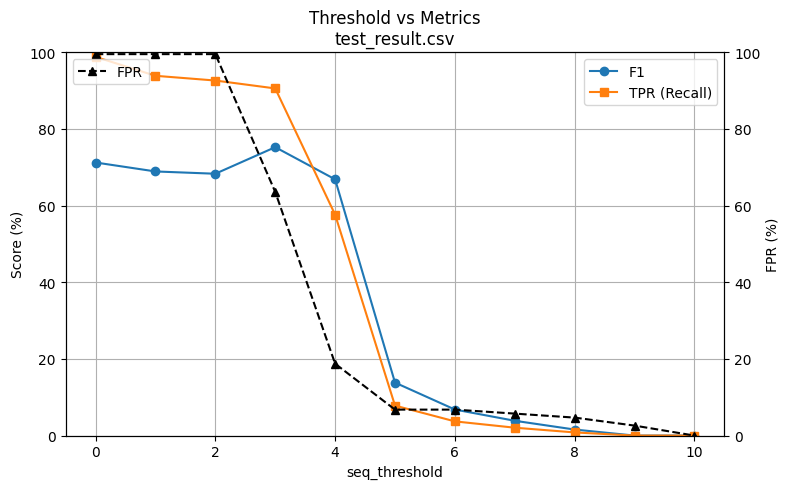

In [16]:
a.plot_threshold_metrics(Path("../archive/13/test_result.csv"))

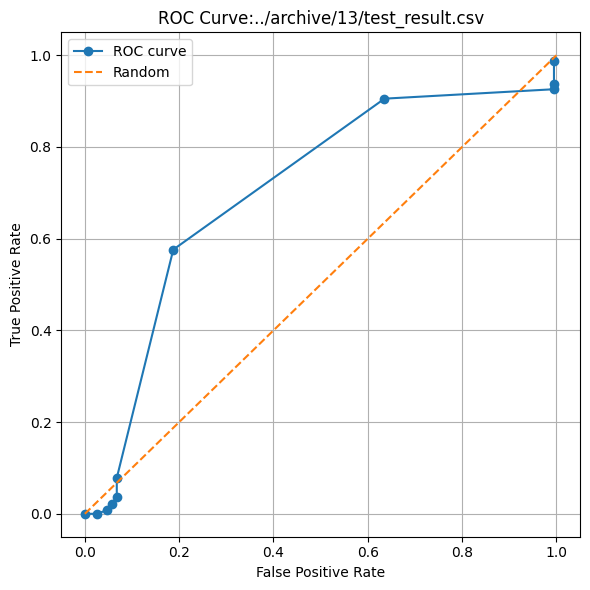

In [18]:
a.plot_roc(Path("../archive/13/test_result.csv"))